# CMA-ES

In [1]:
# ! pip install cma "gymnasium[box2d]>=1.0" "stable-baselines3>=2.3"

In [2]:
import numpy as np
import cma
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd
import gymnasium
import torch
import torch.nn as nn
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
from typing import Callable

### Optimization Problems

This cell defines three common benchmark functions, Sphere, Rosenbrock, and Rastrigin, used to test optimization algorithms. We also used these functions earlier to evaluate Adam and Momentum.

In [3]:
def sphere(x: np.ndarray) -> float:
    return float(np.sum(x**2))


def rosenbrock(x: np.ndarray) -> float:
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1.0 - x[:-1]) ** 2.0))


def rastrigin(x: np.ndarray) -> float:
    A: float = 10.0
    return float(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))

### Helper functions

Convergence plot and animation.

In [4]:
def plot_convergence(histories: dict[str, list[float]]) -> None:
    plt.figure()
    for name, fitness in histories.items():
        plt.plot(fitness, label=name)
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.title("CMA-ES Convergence")
    plt.legend()
    plt.grid(True)
    plt.show()

def animate_distribution(
    func: Callable[[np.ndarray], float],
    mu_history: list[np.ndarray],
    cov_history: list[np.ndarray],
    bounds: tuple[float, float] = (-5, 5),
    frames: int = 50,
    filename: str = "cma_es_animation.mp4",
) -> None:
    x = np.linspace(bounds[0], bounds[1], 200)
    y = np.linspace(bounds[0], bounds[1], 200)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    Z = np.array([func(pt) for pt in coords]).reshape(X.shape)

    fig, ax = plt.subplots()
    levels = np.logspace(np.log10(Z.min() + 1e-6), np.log10(Z.max()), 30)

    def update(frame_index: int) -> None:
        ax.clear()
        ax.contour(X, Y, Z, levels=levels, cmap="viridis")
        mu = mu_history[frame_index]
        cov = cov_history[frame_index]
        vals, vecs = np.linalg.eigh(cov)
        angle = float(np.degrees(np.arctan2(vecs[0, 1], vecs[0, 0])))
        width, height = 2 * np.sqrt(vals)
        ellipse = Ellipse(
            xy=mu,
            width=width,
            height=height,
            angle=angle,
            edgecolor="red",
            facecolor="none",
            lw=2,
        )
        ax.add_patch(ellipse)
        ax.plot(mu[0], mu[1], "ro")
        ax.set_title(f"Generation {frame_index}")
        ax.set_xlim(bounds)
        ax.set_ylim(bounds)

    anim = FuncAnimation(fig, update, frames=min(frames, len(mu_history)), interval=200)
    anim.save(filename, writer="ffmpeg")
    print(f"Animation saved to {filename}")

### Running CMA-ES

In [5]:
from dataclasses import dataclass

@dataclass
class CMAESResult:
    best_fitness: list[float]
    mean_history: list[np.ndarray]
    cov_history: list[np.ndarray]
    sigma_history: list[float]

def run_cma_es(
    func: Callable[[np.ndarray], float],
    x0: np.ndarray,
    sigma0: float,
    max_iterations: int = 100
) -> CMAESResult:
    # TODO: Implement this function
    # TODO: Use cma.CMAEvolutionStrategy from pycma: https://pypi.org/project/cma/
    # Hint: Use ask and tell methods
    es = cma.CMAEvolutionStrategy(
        x0=x0,
        sigma0=sigma0,
        inopts={"verbose": -9}
    )

    best_fitness = []
    mean_history = []
    cov_history = []
    sigma_history = []

    best_so_far = np.inf

    for _ in range(max_iterations):
        solutions = es.ask()

        fitness_values = [
            func(np.array(solution))
            for solution in solutions
        ]

        es.tell(solutions, fitness_values)

        best_so_far = min(best_so_far, min(fitness_values))

        best_fitness.append(best_so_far)
        mean_history.append(es.mean.copy())
        cov_history.append(es.C.copy())
        sigma_history.append(es.sigma)

    return CMAESResult(
        best_fitness=best_fitness,
        mean_history=mean_history,
        cov_history=cov_history,
        sigma_history=sigma_history
    )

# Komentarz
Ten fragment uruchamia algorytm CMA-ES dla podanej funkcji. W każdej iteracji algorytm tworzy nowe rozwiązania, ocenia je, a potem aktualizuje swój sposób szukania minimum. Zapisywane są też: najlepszy wynik, średnia, macierz kowariancji i wartość `sigma`, aby później można było przeanalizować przebieg optymalizacji.

### Ex. 1: Impact of the Starting Point
1.	Choose Rosenbrock in 2D.
2.	Run CMA-ES from at least five widely separated initial means (e.g., [-4,-4], [-1,3], [5,5]).
3.	Plot convergence curves and report:
- best fitness vs. generation,
- total evaluations to reach $f(x)\lt10^{-8}$ (or termination).
4.	Briefly discuss sensitivity to the start point. Prepare GIFs for two different starting points.

Hint: use `sigma0 = 0.5` and `max_iter = 250`.

In [6]:
# Ex. 1: Impact of the Starting Point
start_points = [
    np.array([-4.0, -4.0]),
    np.array([-1.0, 3.0]),
    np.array([5.0, 5.0]),
    np.array([4.0, -3.0]),
    np.array([-3.0, 4.0])
]

sigma0 = 0.5
max_iter = 250
threshold = 1e-8

results = {}

for x0 in start_points:
    label = f"x0 = {x0.tolist()}"
    
    result = run_cma_es(
        func=rosenbrock,
        x0=x0,
        sigma0=sigma0,
        max_iterations=max_iter
    )
    
    results[label] = result

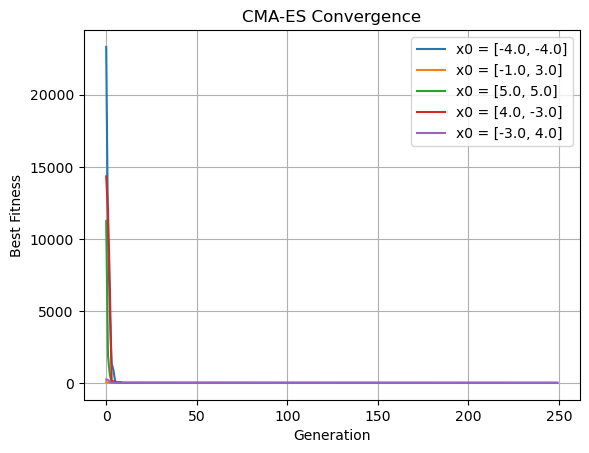

In [7]:
#Wykres zbieżności: best fitness vs generation
plot_convergence({
    label: result.best_fitness
    for label, result in results.items()
})

# Komentarz
### Wykres zbieżności

Na wykresie widać, że dla wszystkich punktów startowych algorytm bardzo szybko zmniejszył wartość funkcji Rosenbrocka. Po początkowych generacjach krzywe praktycznie się pokrywają, co oznacza stabilną zbieżność niezależnie od startu.

In [8]:
# Liczba ewaluacji potrzebna do osiągnięcia f(x) < 1e-8

# Dla 2D pycma domyślnie używa populacji:
population_size = 4 + int(3 * np.log(2))

summary = []

for label, result in results.items():
    reached = False
    evaluations = len(result.best_fitness) * population_size

    for generation, fitness in enumerate(result.best_fitness, start=1):
        if fitness < threshold:
            reached = True
            evaluations = generation * population_size
            break

    summary.append({
        "start point": label,
        "best fitness": result.best_fitness[-1],
        "generations": len(result.best_fitness),
        "evaluations": evaluations,
        "reached threshold": reached
    })

summary_df = pd.DataFrame(summary)
summary_df

,start point,best fitness,generations,evaluations,reached threshold
0,"x0 = [-4.0, -4.0]",1.232595e-30,250,810,True
1,"x0 = [-1.0, 3.0]",0.000000e+00,250,852,True
2,"x0 = [5.0, 5.0]",0.000000e+00,250,684,True
3,"x0 = [4.0, -3.0]",0.000000e+00,250,720,True
4,"x0 = [-3.0, 4.0]",0.000000e+00,250,750,True


# Komentarz
Wszystkie uruchomienia osiągnęły próg  mniejszy niż 10^-8, więc CMA-ES poradził sobie dobrze dla każdego punktu startowego. Najmniej ewaluacji potrzebował start z punktu [5, 5] - 684, a najwięcej start z [-1, 3] - 852. Różnice pokazują, że punkt startowy ma wpływ na szybkość zbieżności, ale nie przeszkodził w znalezieniu minimum.

MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved to rosenbrock_start_-4_-4.gif


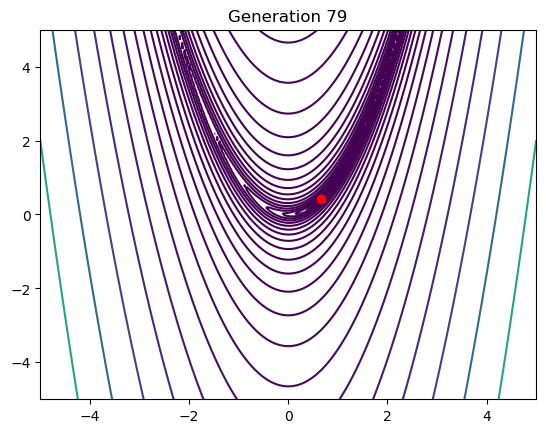

In [9]:
# GIF dla pierwszego punktu startowego

result_1 = results["x0 = [-4.0, -4.0]"]

full_cov_history_1 = [
    (sigma ** 2) * cov
    for sigma, cov in zip(result_1.sigma_history, result_1.cov_history)
]

animate_distribution(
    rosenbrock,
    result_1.mean_history,
    full_cov_history_1,
    bounds=(-5, 5),
    frames=80,
    filename="rosenbrock_start_-4_-4.gif"
)

# Komentarz

### Animacja dla startu [-4, -4]

Na obrazie widać, że algorytm przesunął średnią rozkładu w okolice minimum funkcji Rosenbrocka. CMA-ES dopasowuje kształt obszaru poszukiwań do wąskiej doliny funkcji, dzięki czemu może skuteczniej szukać minimum.

MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved to rosenbrock_start_5_5.gif


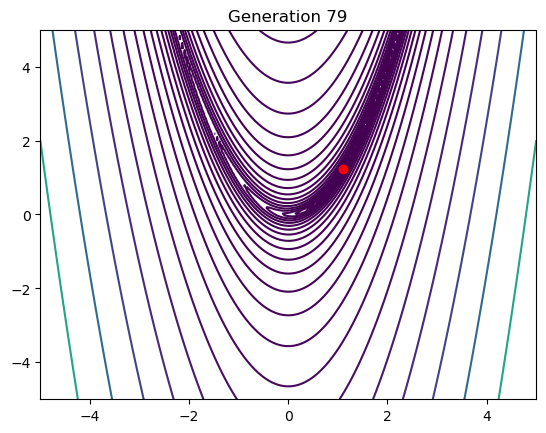

In [10]:
# GIF dla drugiego punktu startowego

result_2 = results["x0 = [5.0, 5.0]"]

full_cov_history_2 = [
    (sigma ** 2) * cov
    for sigma, cov in zip(result_2.sigma_history, result_2.cov_history)
]

animate_distribution(
    rosenbrock,
    result_2.mean_history,
    full_cov_history_2,
    bounds=(-5, 5),
    frames=80,
    filename="rosenbrock_start_5_5.gif"
)

# Komentarz

### Animacja dla startu [5, 5]

Dla tego punktu startowego algorytm również zbliżył się do minimum, mimo że zaczynał z innej części przestrzeni. Rozkład wyszukiwania został przesunięty w stronę doliny Rosenbrocka, co pokazuje, że CMA-ES potrafi dostosować kierunek poszukiwań do kształtu funkcji.

# Komentarz
W tym zadaniu sprawdzono, jak punkt startowy wpływa na działanie algorytmu CMA-ES dla funkcji Rosenbrocka. Algorytm został uruchomiony z kilku różnych, oddalonych od siebie punktów początkowych. Następnie porównano przebieg zbieżności, czyli zmianę najlepszego wyniku w kolejnych generacjach. Dodatkowo policzono, ile ocen funkcji było potrzebnych do osiągnięcia bardzo małej wartości błędu. Dzięki animacjom można zobaczyć, jak CMA-ES przesuwa i dopasowuje swój rozkład wyszukiwania w zależności od miejsca startu.

### Ex. 2: Effect of the Initial Global Step‐Size $\sigma_0$
1. Use [2,2] at starting point on the Rastrigin function.
2. Test $\sigma_0\in\{0.1,\,0.5,\,1,\,2,\,5\}$.
3. Record and plot
- final fitness after a fixed budget (e.g. 1000 evals)
- evolution of es.sigma over time (log scale).
4. Explain why too-small and too-large $\sigma_0$ hurt performance, relating findings to the adaptation rule.

In [16]:
# Wpływ początkowego globalnego rozmiaru kroku

x0 = np.array([2.0, 2.0])

sigma_values = [0.1, 0.5, 1.0, 2.0, 5.0]

eval_budget = 1000
population_size = 4 + int(3 * np.log(len(x0)))
max_iter = eval_budget // population_size

results_sigma = {}

for sigma0 in sigma_values:
    result = run_cma_es(
        func=rastrigin,
        x0=x0,
        sigma0=sigma0,
        max_iterations=max_iter
    )
    
    results_sigma[f"sigma0 = {sigma0}"] = result

In [17]:
# Final fitness po stałym budżecie ewaluacji

summary_sigma = []

for label, result in results_sigma.items():
    summary_sigma.append({
        "sigma0": label,
        "final fitness": result.best_fitness[-1],
        "generations": len(result.best_fitness),
        "evaluations": len(result.best_fitness) * population_size
    })

summary_sigma_df = pd.DataFrame(summary_sigma)
summary_sigma_df

,sigma0,final fitness,generations,evaluations
0,sigma0 = 0.1,7.959662,166,996
1,sigma0 = 0.5,7.959662,166,996
2,sigma0 = 1.0,7.959662,166,996
3,sigma0 = 2.0,1.989918,166,996
4,sigma0 = 5.0,0.994959,166,996


# Komentarz
Najlepszy wynik uzyskano dla sigma0 = 5.0, gdzie final fitness wyniósł około 0.995. Najsłabiej wypadły małe wartości sigma0, które zatrzymały się na poziomie około 7.96. Oznacza to, że przy zbyt małym kroku algorytm miał problem z wyjściem z lokalnego minimum.

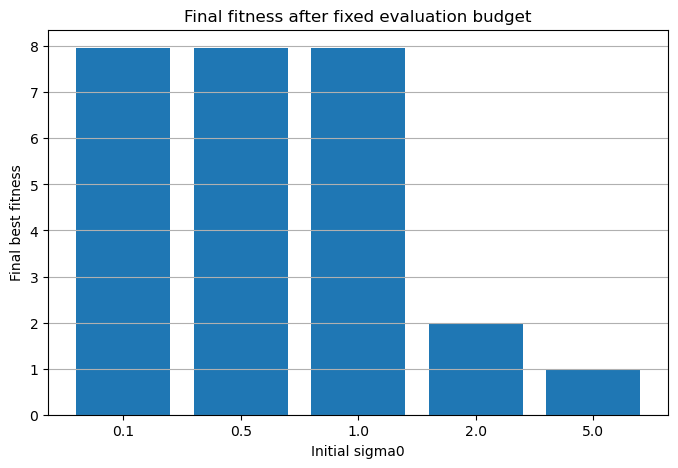

In [18]:
# Wykres final fitness dla różnych sigma0

plt.figure(figsize=(8, 5))

plt.bar(
    [str(s) for s in sigma_values],
    [results_sigma[f"sigma0 = {s}"].best_fitness[-1] for s in sigma_values]
)

plt.xlabel("Initial sigma0")
plt.ylabel("Final best fitness")
plt.title("Final fitness after fixed evaluation budget")
plt.grid(axis="y")
plt.show()

# Komentarze
### Wykres final fitness

Wykres słupkowy dobrze pokazuje różnicę między wartościami sigma0. Małe wartości kroku początkowego dają podobnie słabe wyniki, natomiast większe wartości pozwalają znaleźć lepsze minimum. W tym eksperymencie większa eksploracja na początku była korzystna.

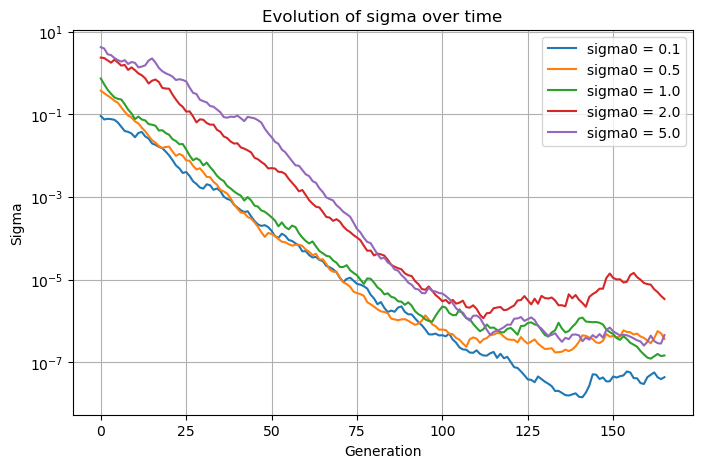

In [19]:
# Ewolucja sigma w czasie, skala logarytmiczna

plt.figure(figsize=(8, 5))

for label, result in results_sigma.items():
    plt.plot(result.sigma_history, label=label)

plt.yscale("log")
plt.xlabel("Generation")
plt.ylabel("Sigma")
plt.title("Evolution of sigma over time")
plt.legend()
plt.grid(True)
plt.show()

# Komentarze
### Wykres ewolucji sigma

Na wykresie widać, że dla wszystkich przypadków sigma stopniowo maleje. Oznacza to, że CMA-ES najpierw przeszukuje większy obszar, a potem zawęża poszukiwania. Dla większych wartości początkowych, algorytm zaczyna szerzej, dzięki czemu łatwiej omija lokalne minima funkcji Rastrigina.

### Ex. 3: Visualising the Covariance Matrix Adaptation
1. On Rastrigin (and Sphere) in 2D, log es.C every 5 generations.
2. Use the provided `animate_distribution` to produce a GIF showing the shrinking and rotation of the sampling ellipse.
3. Submit the animation and two short observations about what the animation reveals regarding step-size vs. shape adaptation.

In [24]:
# Wizualizacja adaptacji macierzy kowariancji

x0 = np.array([2.0, 2.0])
sigma0 = 2.0
max_iter = 100

result_rastrigin = run_cma_es(
    func=rastrigin,
    x0=x0,
    sigma0=sigma0,
    max_iterations=max_iter
)

result_sphere = run_cma_es(
    func=sphere,
    x0=x0,
    sigma0=sigma0,
    max_iterations=max_iter
)

In [25]:
# Bierzemy historię co 5 generacji

step = 5

def sample_every_5(result, step=5):
    mean_hist = result.mean_history[::step]
    cov_hist = result.cov_history[::step]
    sigma_hist = result.sigma_history[::step]

    full_cov_hist = [
        (sigma ** 2) * cov
        for sigma, cov in zip(sigma_hist, cov_hist)
    ]
    
    return mean_hist, full_cov_hist

ras_mean, ras_cov = sample_every_5(result_rastrigin, step=step)
sph_mean, sph_cov = sample_every_5(result_sphere, step=step)

MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved to rastrigin_covariance.gif


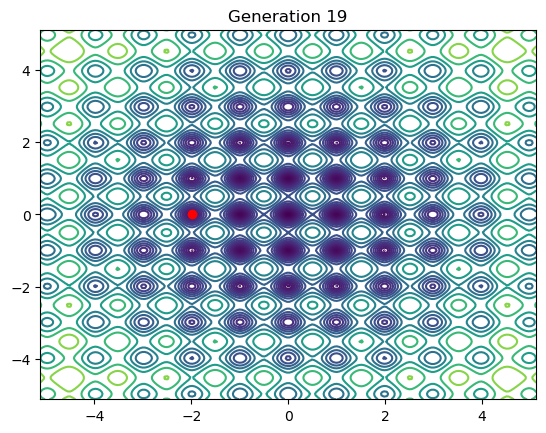

In [26]:
# GIF dla Rastrigina

animate_distribution(
    rastrigin,
    ras_mean,
    ras_cov,
    bounds=(-5.12, 5.12),
    frames=len(ras_mean),
    filename="rastrigin_covariance.gif"
)

# Komentarz
### Rastrigin

Na animacji widać, że CMA-ES zaczyna od szerokiej elipsy, więc bada większy obszar funkcji. Jest to ważne dla Rastrigina, ponieważ funkcja ma wiele lokalnych minimów. Większa elipsa oznacza lepszą eksplorację i większą szansę na uniknięcie zbyt szybkiego utknięcia w jednym miejscu.

MovieWriter ffmpeg unavailable; using Pillow instead.


Animation saved to sphere_covariance.gif


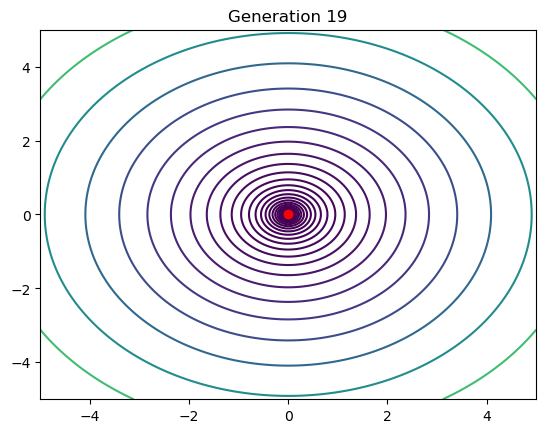

In [23]:
# GIF dla Sphere

animate_distribution(
    sphere,
    sph_mean,
    sph_cov,
    bounds=(-5.0, 5.0),
    frames=len(sph_mean),
    filename="sphere_covariance.gif"
)

# Komentarz
### Sphere
Dla funkcji Sphere powierzchnia jest gładka i symetryczna, dlatego elipsa zachowuje bardziej regularny, prawie okrągły kształt. Algorytm głównie zmniejsza rozmiar kroku sigma, ponieważ nie musi mocno zmieniać kierunku ani kształtu rozkładu.

## Part 2: CMA-ES for Reinforcement Learning

So far we have tested CMA-ES on synthetic benchmark functions where we know the true optimum. Now we apply it to a real control task: **LunarLander-v3**.

### The environment
LunarLander-v3 (Box2D) is a classic RL benchmark:
- **Observation**: 8-D continuous vector (lander position, velocity, angle, angular velocity, leg contact flags).
- **Action**: 4 discrete actions (do nothing, fire left engine, fire main engine, fire right engine).
- **Reward**: dense — shaped by distance to landing pad, fuel used, crash/landing bonus.

### Why this problem?
LunarLander with an MLP policy has ~200 parameters, which is:
- large enough that the covariance matrix has real work to do,
- small enough that CMA-ES fits in a few minutes on a laptop,
- non-differentiable end-to-end (argmax over discrete actions), so gradient-based methods cannot be applied naively.

### Policy architecture
A tiny MLP with tanh activations: 8 → 16 → 4 logits, argmax for action selection. Total parameters: `8*16 + 16 + 16*4 + 4 = 212`. We flatten all weights and biases into a single vector `θ ∈ ℝ²¹²` so CMA-ES can treat the whole policy as a point in parameter space.

In [27]:
ENV_NAME: str = "LunarLander-v3"
OBS_DIM: int = 8
ACT_DIM: int = 4
HIDDEN: int = 16
N_PARAMS: int = OBS_DIM * HIDDEN + HIDDEN + HIDDEN * ACT_DIM + ACT_DIM


class MLPPolicy(nn.Module):
    """Tiny MLP: obs -> hidden (tanh) -> logits -> argmax action."""

    def __init__(self, obs_dim: int = OBS_DIM, hidden: int = HIDDEN, act_dim: int = ACT_DIM) -> None:
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, act_dim),
        )

    def forward(self, obs: torch.Tensor) -> torch.Tensor:
        return self.net(obs)

    @torch.no_grad()
    def act(self, obs: np.ndarray) -> int:
        logits = self.forward(torch.as_tensor(obs, dtype=torch.float32))
        return int(torch.argmax(logits).item())


def set_params(policy: MLPPolicy, flat: np.ndarray) -> None:
    """Copy a flat parameter vector into the policy's weights/biases."""
    assert flat.shape == (N_PARAMS,), f"expected {N_PARAMS} params, got {flat.shape}"
    offset = 0
    for p in policy.parameters():
        n = p.numel()
        p.data.copy_(torch.as_tensor(flat[offset : offset + n], dtype=torch.float32).view_as(p))
        offset += n


def get_params(policy: MLPPolicy) -> np.ndarray:
    """Flatten the policy's weights/biases into a single vector."""
    return np.concatenate([p.detach().cpu().numpy().ravel() for p in policy.parameters()])


def rollout(policy: MLPPolicy, env: gymnasium.Env, seed: int | None = None) -> tuple[float, int]:
    """Run one episode; return (total reward, number of env steps)."""
    obs, _ = env.reset(seed=seed)
    total = 0.0
    steps = 0
    terminated = truncated = False
    while not (terminated or truncated):
        action = policy.act(obs)
        obs, reward, terminated, truncated, _ = env.step(action)
        total += float(reward)
        steps += 1
    return total, steps


def evaluate_policy(
    flat_params: np.ndarray,
    env: gymnasium.Env,
    policy: MLPPolicy,
    n_episodes: int = 3,
    base_seed: int = 0,
) -> tuple[float, int]:
    """Average reward over `n_episodes` with fixed episode seeds (common random numbers).

    Using the same seeds across candidates reduces the noise in pairwise comparisons
    between policies — an antithetic / CRN variance-reduction trick."""
    set_params(policy, flat_params)
    rewards: list[float] = []
    total_steps = 0
    for i in range(n_episodes):
        r, s = rollout(policy, env, seed=base_seed + i)
        rewards.append(r)
        total_steps += s
    return float(np.mean(rewards)), total_steps

### Shared budget

To make the comparison against baselines in Ex. 6 fair, we cap every method at the same number of *environment steps*. This is the currency that matters in RL — wall-clock varies by implementation, but env-steps are identical across methods.

In [32]:
BUDGET_STEPS: int = 50_000
EPISODES_PER_EVAL: int = 1
POPSIZE: int = 8
SIGMA0_RL: float = 0.5
#zmniejszone wartosci

### Ex. 4: Train LunarLander with CMA-ES

1. Create a `MLPPolicy` and a single persistent `gymnasium.make(ENV_NAME)` environment.
2. Write `train_cma_es_rl(...)` that uses `cma.CMAEvolutionStrategy` (ask/tell loop) to **maximize** `evaluate_policy(θ)`. Remember CMA-ES minimizes — negate the reward.
3. Stop when cumulative env-steps exceed `BUDGET_STEPS`.
4. Per generation, record: mean reward of the population, best-so-far reward, cumulative env-steps.
5. Return a dict: `{"steps": [...], "best": [...], "mean": [...], "best_params": np.ndarray}`. We'll reuse this structure for all methods in Ex. 5.
6. Plot reward vs. cumulative env-steps. Render one final rollout with `gymnasium.make(ENV_NAME, render_mode="human")` to see the learned behaviour.

**Hints**
- `popsize=POPSIZE`, `sigma0=SIGMA0_RL`, `x0=np.zeros(N_PARAMS)`.
- `cma.CMAEvolutionStrategy(x0, sigma0, {"popsize": POPSIZE, "verbose": -9})`.
- Use `EPISODES_PER_EVAL` episodes per candidate with the *same* base_seed across the whole population in one generation (CRN). Bump the base_seed each generation so CMA-ES doesn't overfit to three fixed seeds.

In [33]:
# TODO: implement train_cma_es_rl and run it here.
# Expected return shape: dict(steps=list[int], best=list[float], mean=list[float], best_params=np.ndarray)
def train_cma_es_rl(
    budget_steps: int = BUDGET_STEPS,
    episodes_per_eval: int = EPISODES_PER_EVAL,
    popsize: int = POPSIZE,
    sigma0: float = SIGMA0_RL,
) -> dict:
    
    env = gymnasium.make(ENV_NAME)
    policy = MLPPolicy()

    x0 = np.zeros(N_PARAMS)

    es = cma.CMAEvolutionStrategy(
        x0,
        sigma0,
        {
            "popsize": popsize,
            "verbose": -9
        }
    )

    steps_history = []
    best_history = []
    mean_history = []

    total_steps = 0
    best_reward = -np.inf
    best_params = x0.copy()

    generation = 0

    while total_steps < budget_steps:
        solutions = es.ask()

        rewards = []
        fitness_values = []

        base_seed = generation * episodes_per_eval

        for solution in solutions:
            solution = np.asarray(solution)

            reward, steps = evaluate_policy(
                flat_params=solution,
                env=env,
                policy=policy,
                n_episodes=episodes_per_eval,
                base_seed=base_seed
            )

            total_steps += steps
            rewards.append(reward)

            # CMA-ES minimalizuje, więc maksymalizację nagrody zamieniamy na minimalizację -reward
            fitness_values.append(-reward)

            if reward > best_reward:
                best_reward = reward
                best_params = solution.copy()

        es.tell(solutions, fitness_values)

        steps_history.append(total_steps)
        mean_history.append(float(np.mean(rewards)))
        best_history.append(float(best_reward))

        generation += 1

    env.close()

    return {
        "steps": steps_history,
        "best": best_history,
        "mean": mean_history,
        "best_params": best_params
    }


cma_es_result = train_cma_es_rl()

# Komentarz
W tym fragmencie algorytm CMA-ES jest używany do trenowania polityki dla środowiska LunarLander. Każdy kandydat to wektor parametrów sieci neuronowej. Dla każdego wektora uruchamianych jest kilka epizodów, a średnia nagroda ocenia jakość polityki. Ponieważ CMA-ES minimalizuje funkcję celu, nagroda jest zamieniana na wartość ujemną. W każdej generacji zapisywana jest średnia nagroda populacji, najlepsza dotychczasowa nagroda oraz liczba wykonanych kroków środowiska.

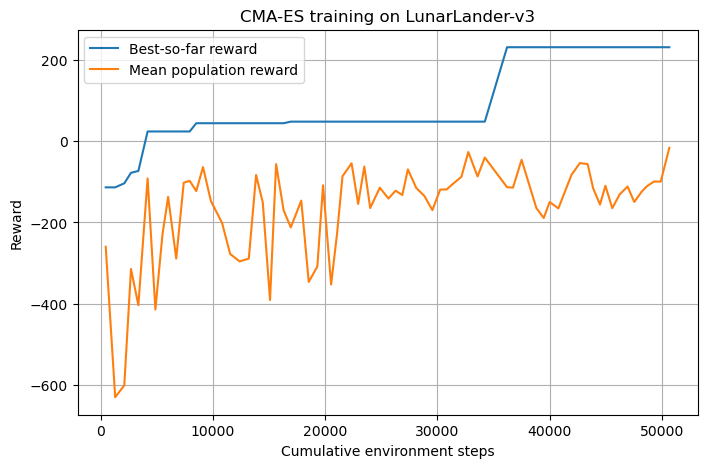

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(cma_es_result["steps"], cma_es_result["best"], label="Best-so-far reward")
plt.plot(cma_es_result["steps"], cma_es_result["mean"], label="Mean population reward")

plt.xlabel("Cumulative environment steps")
plt.ylabel("Reward")
plt.title("CMA-ES training on LunarLander-v3")
plt.legend()
plt.grid(True)
plt.show()

# Komentarz
Na wykresie widać, że najlepsza dotychczasowa nagroda rośnie skokowo. Początkowo polityki działają słabo i mają ujemne nagrody, ale po kilku tysiącach kroków CMA-ES znajduje pierwsze lepsze rozwiązania. Największa poprawa pojawia się około 35 000–37 000 kroków, gdzie najlepsza nagroda przekracza 200, co oznacza udane lądowanie.

Średnia nagroda populacji jest dużo bardziej niestabilna i przez większość czasu pozostaje ujemna. To normalne, ponieważ CMA-ES cały czas testuje różne warianty parametrów, z których wiele daje słabe wyniki. Ważne jest jednak to, że najlepszy znaleziony wynik systematycznie się poprawia.

In [35]:
render_env = gymnasium.make(ENV_NAME, render_mode="human")
final_policy = MLPPolicy()

set_params(final_policy, cma_es_result["best_params"])

reward, steps = rollout(final_policy, render_env, seed=123)

print("Final rollout reward:", reward)
print("Steps:", steps)

render_env.close()

Final rollout reward: -80.37093735625989
Steps: 68


# Komentarz
Mimo że podczas treningu CMA-ES znalazł politykę z nagrodą powyżej 200, końcowy test dla innego seeda dał wynik ujemny. Oznacza to, że znaleziona polityka nie jest jeszcze stabilna i dobrze działa tylko dla części warunków początkowych. Jest to typowe przy małym budżecie kroków oraz małej liczbie epizodów używanych do oceny kandydata.

### Ex. 5: Baselines — is CMA-ES actually doing something clever?

CMA-ES shows nice-looking learning curves, but before we credit the *covariance adaptation* we need a baseline. Two questions:

- **Does search matter at all?** → compare to **random search**: sample i.i.d. Gaussian parameter vectors, keep the best. Same evaluation protocol, same env-step budget.
- **Does being an RL algorithm matter?** → compare to **PPO** from Stable-Baselines3, a standard on-policy actor-critic method. Same env, same env-step budget.

Plot all three on a single chart: *best-so-far reward* (y) vs. *cumulative env-steps* (x). That is the only fair axis — not generations, not wall-clock.

#### Ex. 5a: Random search baseline

Implement `train_random_search(...)` that draws candidates from $\mathcal{N}(0, \sigma_0^2 I)$ and keeps the best, using `evaluate_policy` and `BUDGET_STEPS`. Return the same dict format as `train_cma_es_rl`.

In [36]:
# TODO: implement train_random_search and run it here.
def train_random_search(
    budget_steps: int = BUDGET_STEPS,
    episodes_per_eval: int = EPISODES_PER_EVAL,
    popsize: int = POPSIZE,
    sigma0: float = SIGMA0_RL,
) -> dict:
    
    env = gymnasium.make(ENV_NAME)
    policy = MLPPolicy()

    steps_history = []
    best_history = []
    mean_history = []

    total_steps = 0
    best_reward = -np.inf
    best_params = np.zeros(N_PARAMS)

    generation = 0

    while total_steps < budget_steps:
        rewards = []

        # Ten sam base_seed dla całej populacji w jednej generacji
        base_seed = generation * episodes_per_eval

        for _ in range(popsize):
            # Losowy kandydat z rozkładu N(0, sigma0^2 I)
            candidate = np.random.normal(
                loc=0.0,
                scale=sigma0,
                size=N_PARAMS
            )

            reward, steps = evaluate_policy(
                flat_params=candidate,
                env=env,
                policy=policy,
                n_episodes=episodes_per_eval,
                base_seed=base_seed
            )

            total_steps += steps
            rewards.append(reward)

            if reward > best_reward:
                best_reward = reward
                best_params = candidate.copy()

            if total_steps >= budget_steps:
                break

        steps_history.append(total_steps)
        mean_history.append(float(np.mean(rewards)))
        best_history.append(float(best_reward))

        print(
            f"Generation: {generation}, "
            f"steps: {total_steps}, "
            f"mean reward: {np.mean(rewards):.2f}, "
            f"best reward: {best_reward:.2f}"
        )

        generation += 1

    env.close()

    return {
        "steps": steps_history,
        "best": best_history,
        "mean": mean_history,
        "best_params": best_params
    }


random_result = train_random_search()

Generation: 0, steps: 544, mean reward: -322.22, best reward: -119.06
Generation: 1, steps: 1275, mean reward: -614.89, best reward: -119.06
Generation: 2, steps: 2250, mean reward: -757.72, best reward: -115.81
Generation: 3, steps: 3095, mean reward: -674.96, best reward: -115.81
Generation: 4, steps: 3991, mean reward: -529.13, best reward: -115.81
Generation: 5, steps: 4783, mean reward: -286.38, best reward: -15.04
Generation: 6, steps: 5501, mean reward: -543.07, best reward: -15.04
Generation: 7, steps: 6144, mean reward: -477.57, best reward: -15.04
Generation: 8, steps: 6717, mean reward: -375.47, best reward: -15.04
Generation: 9, steps: 7365, mean reward: -434.71, best reward: -15.04
Generation: 10, steps: 8303, mean reward: -667.85, best reward: 17.37
Generation: 11, steps: 8898, mean reward: -349.96, best reward: 17.37
Generation: 12, steps: 9485, mean reward: -252.07, best reward: 17.37
Generation: 13, steps: 10092, mean reward: -399.43, best reward: 17.37
Generation: 14,

# Komentarz
Random search przez cały trening losuje niezależne wektory parametrów, więc nie wykorzystuje informacji z poprzednich prób. Na początku najlepsza nagroda była ujemna, a około 8000 kroków udało się znaleźć lepszą politykę. Najlepszy wynik wzrósł później do około 17.37, ale potem już się nie poprawiał.

Średnia nagroda populacji przez większość czasu pozostaje mocno ujemna, co pokazuje, że większość losowych polityk działa słabo. W porównaniu z CMA-ES, który osiągnął wynik powyżej 200, random search wypada dużo gorzej.

#### Ex. 5b: PPO baseline (Stable-Baselines3)

PPO is a policy-gradient method; it trains by sampling actions stochastically, computing advantages, and taking gradient steps on a clipped surrogate objective. It requires a *differentiable* stochastic policy — so SB3 uses its own MLP underneath, with a softmax over actions and an independent value head.

Install once: `pip install stable-baselines3`.

In [37]:
import tempfile
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor


def train_ppo(total_steps: int = BUDGET_STEPS, eval_freq: int = 5_000, seed: int = 0) -> dict:
    """Train PPO on LunarLander-v3. Requires stable-baselines3 >= 2.0 (native Gymnasium support).

    Note: `EvalCallback` only populates `evaluations_timesteps` / `evaluations_results`
    when `log_path` is set — otherwise they remain empty lists. We use a tempdir.
    """
    train_env = Monitor(gymnasium.make(ENV_NAME))
    eval_env = Monitor(gymnasium.make(ENV_NAME))
    log_dir = tempfile.mkdtemp(prefix="ppo_eval_")
    model = PPO(
        "MlpPolicy", 
        train_env,
        policy_kwargs=dict(net_arch=[HIDDEN]),
        learning_rate=3e-4, 
        n_steps=1024, 
        batch_size=64, 
        n_epochs=4,
        gamma=0.99, 
        gae_lambda=0.95, 
        clip_range=0.2,
        verbose=0, 
        seed=seed,
    )
    callback = EvalCallback(
        eval_env, n_eval_episodes=EPISODES_PER_EVAL,
        eval_freq=eval_freq, deterministic=True, verbose=0,
        log_path=log_dir,
    )
    model.learn(total_timesteps=total_steps, callback=callback)
    steps = list(callback.evaluations_timesteps)
    mean_rewards = [float(np.mean(r)) for r in callback.evaluations_results]
    best_so_far: list[float] = []; running = -np.inf
    for r in mean_rewards:
        running = max(running, r); best_so_far.append(running)
    train_env.close(); eval_env.close()
    return {"steps": steps, "best": best_so_far, "mean": mean_rewards, "model": model}

ppo_result = train_ppo()
print(f"PPO collected {len(ppo_result['steps'])} evaluation points")

PPO collected 10 evaluation points


# Komentarz
PPO zostało ocenione 10 razy, ponieważ trening trwał 50 000 kroków środowiska, a ewaluacja była wykonywana co 5 000 kroków.

#### Ex. 5c: Compare all three

Plot best-so-far reward vs. cumulative env-steps for CMA-ES, Random Search, and PPO on the same chart. Add a horizontal line at reward = 200 (the "solved" threshold).

Then answer in 3–5 sentences:
1. Did CMA-ES beat Random Search? If yes — what did the covariance adaptation buy us?
2. How does CMA-ES compare to PPO at the same env-step budget?
3. In what sense is the comparison *unfair* in each direction? (Think: hyperparameter count, bootstrapping in PPO, env-step definition, wall-clock.)

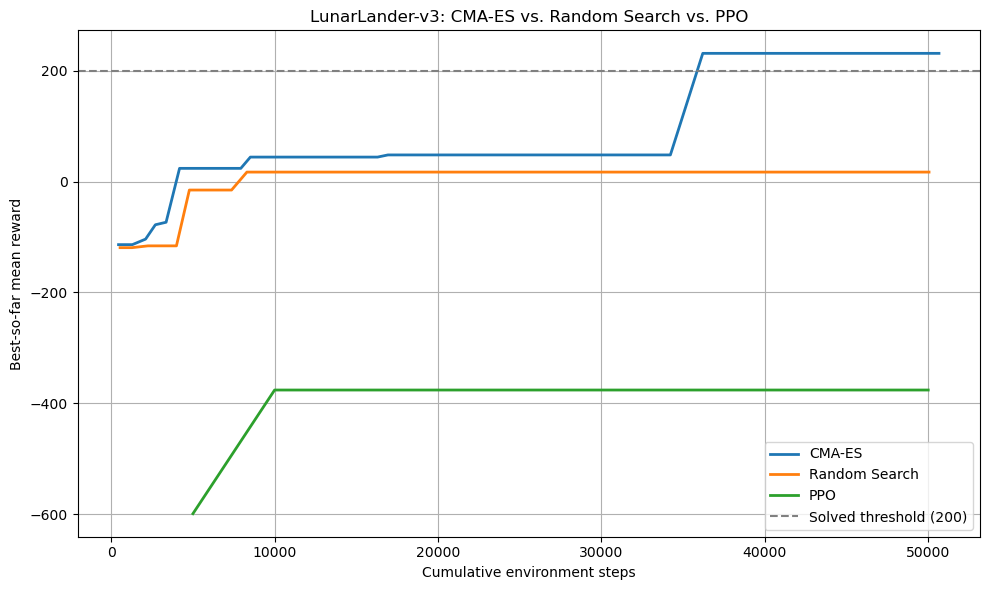

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(cma_es_result["steps"], cma_es_result["best"], label="CMA-ES", linewidth=2)
plt.plot(random_result["steps"], random_result["best"], label="Random Search", linewidth=2)
plt.plot(ppo_result["steps"],   ppo_result["best"],   label="PPO", linewidth=2)
plt.axhline(200, color="gray", linestyle="--", label="Solved threshold (200)")
plt.xlabel("Cumulative environment steps")
plt.ylabel("Best-so-far mean reward")
plt.title("LunarLander-v3: CMA-ES vs. Random Search vs. PPO")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# Komentarz
CMA-ES wyraźnie pokonał random search. Oznacza to, że adaptacja rozkładu w CMA-ES faktycznie pomaga: algorytm nie losuje parametrów całkowicie przypadkowo, tylko uczy się, w których kierunkach warto szukać lepszych polityk.

PPO w tym eksperymencie wypadło najgorzej i nie poprawiło wyniku w ramach budżetu `50 000` kroków. Może to wynikać z tego, że PPO zwykle potrzebuje większego budżetu kroków i odpowiednio dobranych hiperparametrów, żeby dobrze nauczyć się LunarLandera.

Porównanie nie jest całkowicie sprawiedliwe: PPO korzysta z gradientów, funkcji wartości i wielu mechanizmów typowych dla RL, a CMA-ES traktuje cały problem jak czarną skrzynkę. Z drugiej strony CMA-ES może być wolniejszy obliczeniowo, bo każda ocena wymaga uruchomienia wielu epizodów i testowania całej populacji parametrów.

### When is CMA-ES a good fit?


**When to reach for CMA-ES in practice**: black-box or non-differentiable objective; small-to-medium parameter count (up to a few thousand); reward signal is noisy; you have parallel compute; you do not want to tune many hyperparameters. Classic applications: controller tuning, hyperparameter optimization, evolving neural network weights for control tasks, direct optimization of simulator-based designs.

In [39]:
# Watch the trained CMA-ES policy (optional — requires a display)
render_env = gymnasium.make(ENV_NAME, render_mode="human")
policy = MLPPolicy(); set_params(policy, cma_es_result["best_params"])
for i in range(3):
    r, _ = rollout(policy, render_env, seed=10_000 + i)
    print(f"Episode {i}: reward={r:.1f}")
render_env.close()

Episode 0: reward=-69.5
Episode 1: reward=-100.9
Episode 2: reward=-101.7


# Komentarz
Końcowe testy wytrenowanej polityki CMA-ES dały ujemne nagrody, mimo że podczas treningu najlepszy wynik przekroczył próg 200. Aby poprawić stabilność, należałoby zwiększyć budżet treningu oraz oceniać każdego kandydata na większej liczbie epizodów.